<a href="https://colab.research.google.com/github/moist234/ECON3916-Statistical-Machine-Learning/blob/main/Project-01/Project1_Phase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

df = pd.read_csv('lalonde.csv')

In [3]:
# Step 4.1
formula_final = 're78 ~ treat + age + educ + re74 + re75 + black + hispan + married + nodegree'

model_final = smf.ols(formula = formula_final, data=df).fit(cov_type='HC1')
print(model_final.summary())
formula_baseline = 're78 ~ treat'
model_baseline = smf.ols(formula=formula_baseline, data=df).fit(cov_type='HC1')
print(model_baseline.summary())

                            OLS Regression Results                            
Dep. Variable:                   re78   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     9.957
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           2.55e-14
Time:                        00:21:02   Log-Likelihood:                -6297.8
No. Observations:                 614   AIC:                         1.262e+04
Df Residuals:                     604   BIC:                         1.266e+04
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     66.5145   2530.018      0.026      0.9

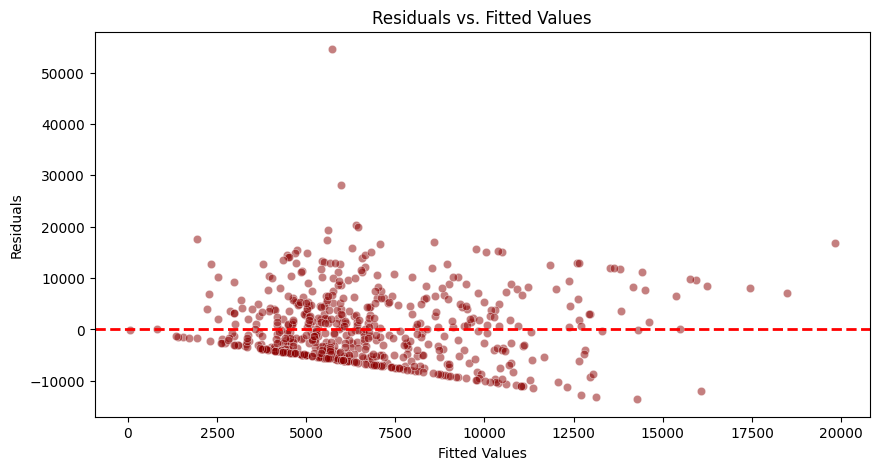

In [4]:
# Step 4.2
# Diagnostic 1
fitted = model_final.fittedvalues
residuals = model_final.resid

plt.figure(figsize=(10,5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5, color='darkred')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

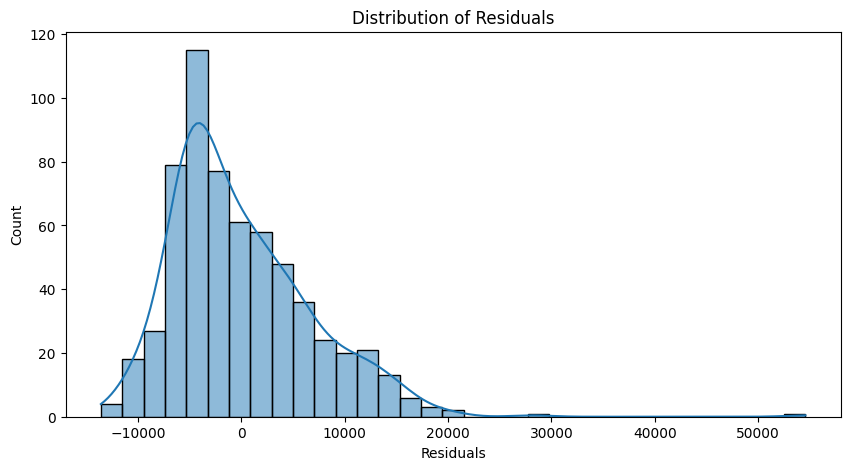

In [5]:
# Diagnostic 2
plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.show()

In [6]:
# Diagnostic 3
print("Table 1: Control Group")
print(df[df['treat'] == 0][['re78', 're74', 're75', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree']].describe())
print("Table 2: Treated Group")
print(df[df['treat'] == 1][['re78', 're74', 're75', 'age', 'educ', 'black', 'hispan', 'married', 'nodegree']].describe())

Table 1: Control Group
               re78          re74          re75         age        educ  \
count    429.000000    429.000000    429.000000  429.000000  429.000000   
mean    6984.169742   5619.236506   2466.484443   28.030303   10.235431   
std     7294.161791   6788.750796   3291.996183   10.786653    2.855238   
min        0.000000      0.000000      0.000000   16.000000    0.000000   
25%      220.181300      0.000000      0.000000   19.000000    9.000000   
50%     4975.505000   2547.047000   1086.726000   25.000000   11.000000   
75%    11688.820000   9277.128000   3881.419000   35.000000   12.000000   
max    25564.670000  25862.320000  18347.230000   55.000000   18.000000   

            black      hispan     married    nodegree  
count  429.000000  429.000000  429.000000  429.000000  
mean     0.202797    0.142191    0.512821    0.596737  
std      0.402552    0.349654    0.500419    0.491126  
min      0.000000    0.000000    0.000000    0.000000  
25%      0.000000    

In [7]:
# Diagnostic 4

Q1 = df['re78'].quantile(0.25)
Q3 = df['re78'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['re78'] < (Q1-1.5*IQR)) | (df['re78'] > (df['re78'] > (Q3 + 1.5 * IQR)))]
print(f"Outliers removed: {len(outliers)}")

df_clean = df[df['re78'] <= (Q3 + 1.5 * IQR)]
model_robust = smf.ols(formula=formula_final, data=df_clean).fit(cov_type='HC1')

print(f"Original treat coef: {model_final.params['treat']:.2f}")
print(f"Robust treat coef: {model_robust.params['treat']:.2f}")
print(model_robust.summary())

Outliers removed: 471
Original treat coef: 1548.24
Robust treat coef: 1100.30
                            OLS Regression Results                            
Dep. Variable:                   re78   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     10.42
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           4.79e-15
Time:                        00:21:03   Log-Likelihood:                -6221.9
No. Observations:                 611   AIC:                         1.246e+04
Df Residuals:                     601   BIC:                         1.251e+04
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

In [8]:
print("\n Robustness Check: Model without Outliers")
print(f"Original treat coef: {model_final.params['treat']:.2f}")
print(f"Robust treat coef: {model_robust.params['treat']:.2f}")
print("\n Full Robust Model Summary")
print(model_robust.summary())


 Robustness Check: Model without Outliers
Original treat coef: 1548.24
Robust treat coef: 1100.30

 Full Robust Model Summary
                            OLS Regression Results                            
Dep. Variable:                   re78   R-squared:                       0.157
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     10.42
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           4.79e-15
Time:                        00:21:03   Log-Likelihood:                -6221.9
No. Observations:                 611   AIC:                         1.246e+04
Df Residuals:                     601   BIC:                         1.251e+04
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----